# Dimensionality Reduction and Ordination

After preprocessing and CLR transformation, the dataset remains high-dimensional. To extract meaningful biological signals from sparse, compositional microbiome data, we employ non-linear dimensionality reduction.

### Methodological Rationale

*   **Why we bypass PCA:** Conventional PCA is explicitly discouraged for microbiome data because it assumes linear relationships and emphasizes false correlations. As [Armstrong et al. (2022)](../Papers/PCA_tsne/GeorgeAmstrong2022.pdf), *Discussion* point out, it fails to capture complex, non-linear patterns. While our CLR transformation solves the compositionality issue, forcing the high-dimensional data through a linear PCA risks stripping away critical non-linear signals before they can be visualized [Xu et al., 2020, *Introduction*](../Papers/PCA_tsne/XueliXu2020.pdf).

*   **Direct Non-Linear Embedding (t-SNE & UMAP) with Aitchison Distance**: To perfectly preserve the local structure of our data, we skip the PCA step entirely. Following the methodology of [Xu et al., 2020](../Papers/PCA_tsne/XueliXu2020.pdf), we compute the Aitchison distance (mathematically equivalent to the Euclidean distance on CLR-transformed data) across all features and feed it directly into the t-SNE and UMAP algorithms. Non-linear methods like t-SNE and UMAP are uniquely capable of revealing biological fine-scale clusters hidden from linear methods [Armstrong et al. (2022)](../Papers/PCA_tsne/GeorgeAmstrong2022.pdf). As [Xu et al., 2020](../Papers/PCA_tsne/XueliXu2020.pdf) demonstrated, bypassing linear pre-filters and applying the Aitchison distance directly to both algorithms ensures they accurately handle the compositionality of the data, leading to superior representations.

### From Geography to Global Signatures

Plotting individual countries often creates visual noise. To make the ordination interpretable, we aggregate the samples into broader socio-ecological groupings:
*   **Continents:** To identify large-scale biogeographical patterns.
*   **Lifestyle Clusters (Western vs. Non-Western):** To evaluate how industrialization and diet shape the microbial fingerprint.

### Implementation

1.  Compute the high-dimensional **Aitchison distance** directly from all CLR-transformed features (bypassing PCA).
2.  Execute **t-SNE** on this complete distance matrix to visualize non-linear structures in 2D.
3.  Evaluate the resulting clusters based on Geography and Lifestyle categories.

In [1]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

In [2]:
# Load the CLR-transformed dataset
file_path = '../data/processed/06_clr_healthy_data.csv'
df = pd.read_csv(file_path)

# Feature selection and label extraction
features = [col for col in df.columns if col.startswith('msp')]
X = df[features]
labels = df['Geography']

In [4]:
# Consolidate results into a single plotting DataFrame
df_plot = pd.DataFrame(X, columns=[f'PC{i+1}' for i in range(X.shape[1])])
df_plot['Geography'] = labels.values

# Step 2: t-SNE (Neighborhood focused)
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X)
df_plot['tsne_1'], df_plot['tsne_2'] = X_tsne[:, 0], X_tsne[:, 1]

# Step 3: UMAP (Global & Local structure balanced)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
df_plot['umap_1'], df_plot['umap_2'] = X_umap[:, 0], X_umap[:, 1] # type: ignore

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


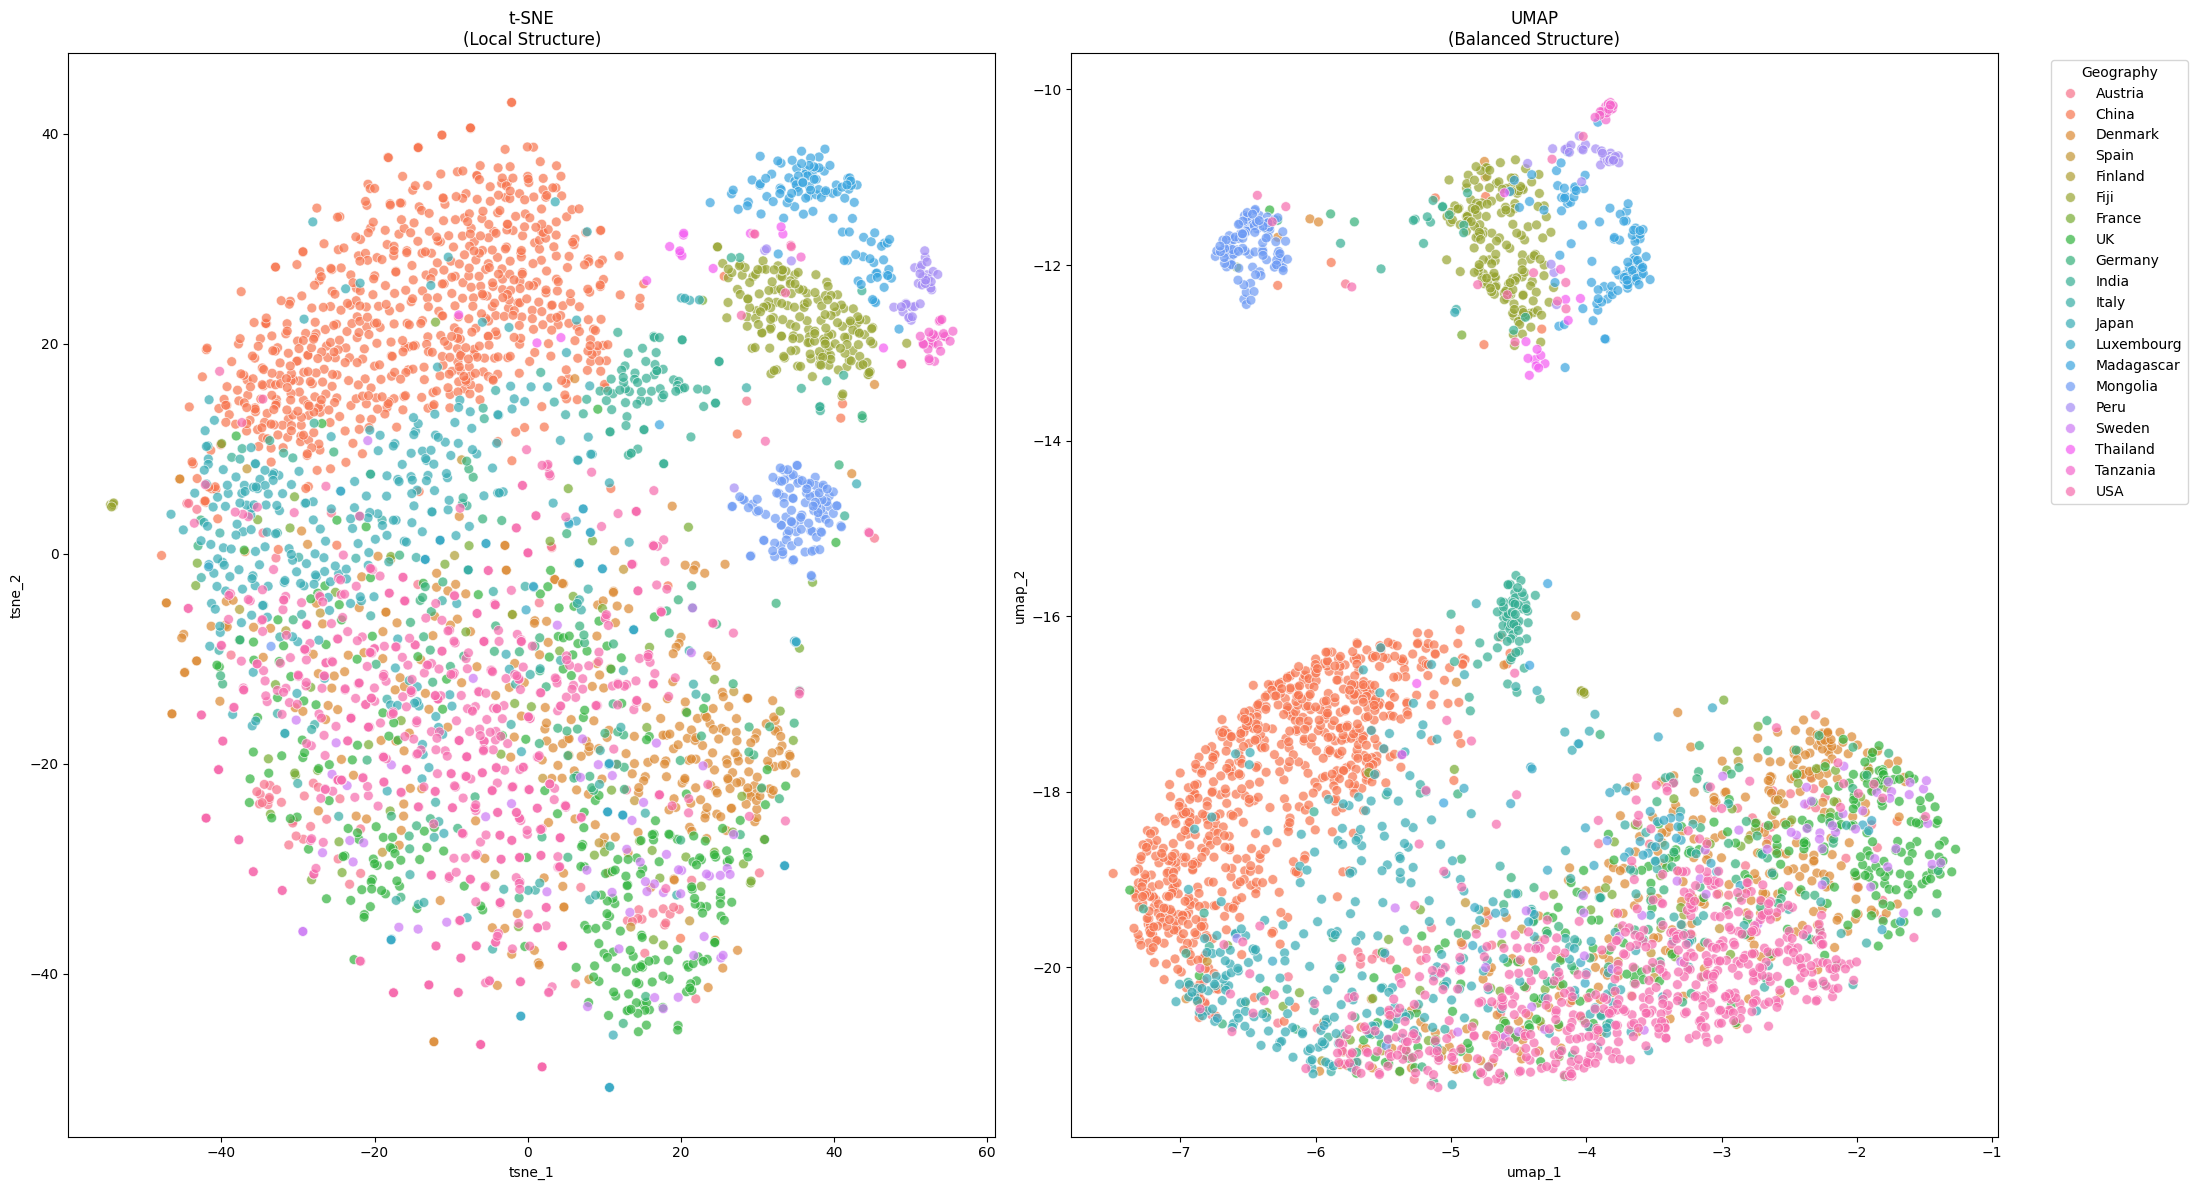

In [17]:
# Visualization: Side-by-side Comparison
fig, axes = plt.subplots(1, 2, figsize=(22, 12))

# Plot t-SNE
sns.scatterplot(data=df_plot, x='tsne_1', y='tsne_2', hue='Geography', ax=axes[0], palette='husl', s=50, alpha=0.7)
axes[0].set_title('t-SNE\n(Local Structure)')
axes[0].get_legend().remove()

# Plot UMAP
sns.scatterplot(data=df_plot, x='umap_1', y='umap_2', hue='Geography', ax=axes[1], palette='husl', s=50, alpha=0.7)
axes[1].set_title('UMAP\n(Balanced Structure)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Geography')

plt.tight_layout()
plt.show()